In [23]:
!pip install nltk
!pip install gensim
!pip install numpy
!pip install contractions
!pip install gradio

In [24]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from tensorflow.keras.callbacks import EarlyStopping
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [25]:
df = pd.read_csv('/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/Task 3/train_racist.csv')

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Total samples: 31962
label
0    29720
1     2242
Name: count, dtype: int64


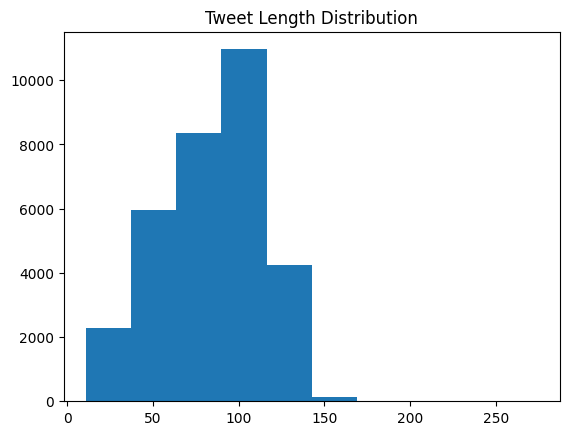

In [26]:
print("Total samples:", len(df))
print(df['label'].value_counts())

df['tweet_length'] = df['tweet'].apply(len)

plt.hist(df['tweet_length'])
plt.title("Tweet Length Distribution")
plt.show()

In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['tweet'].apply(clean_text)

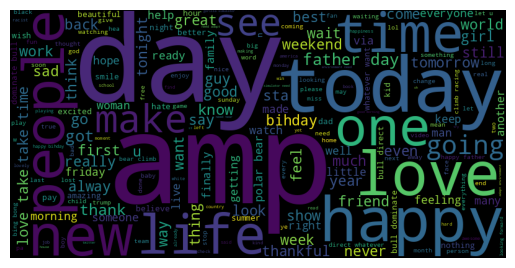

In [28]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

In [29]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f"Using max_len={max_len} (95th percentile)")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

vocab_size = len(tokenizer.word_index) + 1

Using max_len=11 (95th percentile)


In [30]:
import time
model_rnn = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test),
    callbacks=[EarlyStopping(patience=2)]
)

rnn_training_time = time.time() - start_time

print("RNN Training Time:", rnn_training_time, "seconds")


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


800/800 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.9402 - loss: 0.1963 - val_accuracy: 0.9473 - val_loss: 0.1678
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9716 - loss: 0.0867 - val_accuracy: 0.9484 - val_loss: 0.1813
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.9398 - val_loss: 0.2212
RNN Training Time: 67.19005799293518 seconds


In [31]:
model_lstm = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test),
    callbacks=[EarlyStopping(patience=2)]
)

lstm_training_time = time.time() - start_time

print("LSTM Training Time:", lstm_training_time, "seconds")


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9400 - loss: 0.1963 - val_accuracy: 0.9485 - val_loss: 0.1610
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9631 - loss: 0.1077 - val_accuracy: 0.9509 - val_loss: 0.1674
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9753 - loss: 0.0738 - val_accuracy: 0.9462 - val_loss: 0.1790
LSTM Training Time: 59.62913131713867 seconds


In [32]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model_w2v = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

start_time = time.time()

history_w2v = model_w2v.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test),
    callbacks=[EarlyStopping(patience=2)]
)

w2v_training_time = time.time() - start_time

print("Word2Vec LSTM Training Time:", w2v_training_time, "seconds")


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9313 - loss: 0.2123 - val_accuracy: 0.9301 - val_loss: 0.2071
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9383 - loss: 0.1828 - val_accuracy: 0.9374 - val_loss: 0.1836
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9443 - loss: 0.1666 - val_accuracy: 0.9387 - val_loss: 0.1757
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9480 - loss: 0.1539 - val_accuracy: 0.9384 - val_loss: 0.1737
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9530 - loss: 0.1413 - val_accuracy: 0.9445 - val_loss: 0.1720
Word2Vec LSTM Training Time: 51.17604184150696 seconds


In [33]:
def get_metrics(model):
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    }

results = pd.DataFrame([
    get_metrics(model_rnn),
    get_metrics(model_lstm),
    get_metrics(model_w2v)
], index=["RNN", "LSTM", "Word2Vec"])

print(results)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
          Accuracy  Precision    Recall        F1
RNN       0.939778   0.587678  0.540305  0.562997
LSTM      0.946191   0.657534  0.522876  0.582524
Word2Vec  0.944471   0.700000  0.396514  0.506259


In [34]:
from sklearn.metrics import classification_report
for model, name in [(model_rnn, 'RNN'), (model_lstm, 'LSTM'), (model_w2v, 'Word2Vec')]:
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, preds))

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== RNN Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      5934
           1       0.59      0.54      0.56       459

    accuracy                           0.94      6393
   macro avg       0.78      0.76      0.77      6393
weighted avg       0.94      0.94      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
=== LSTM Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5934
           1       0.66      0.52      0.58       459

    accuracy                           0.95      6393
   macro avg       0.81      0.75      0.78      6393
weighted avg       0.94      0.95      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Word2Vec Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5934
      

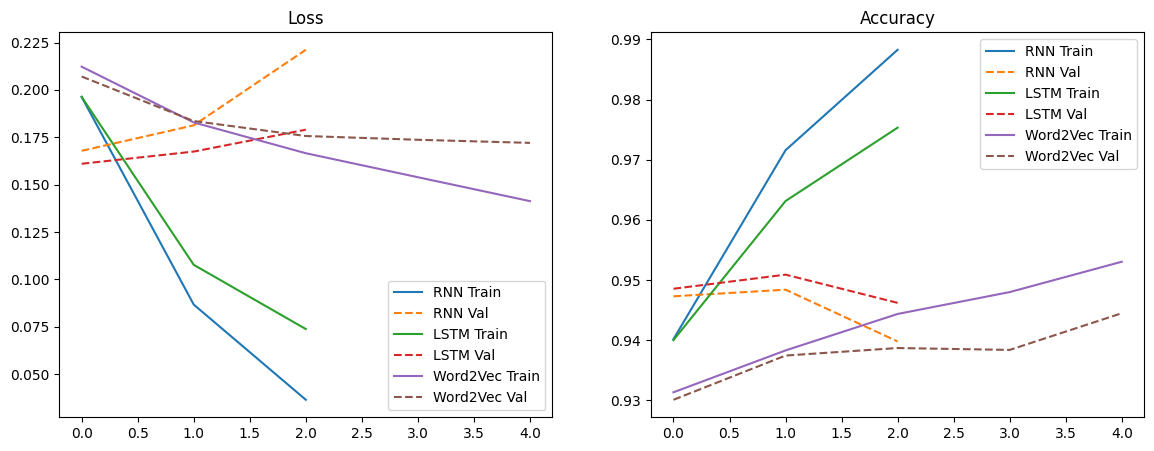

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for history, label in [(history_rnn, 'RNN'), (history_lstm, 'LSTM'), (history_w2v, 'Word2Vec')]:
    axes[0].plot(history.history['loss'], label=f'{label} Train')
    axes[0].plot(history.history['val_loss'], linestyle='--', label=f'{label} Val')
    axes[1].plot(history.history['accuracy'], label=f'{label} Train')
    axes[1].plot(history.history['val_accuracy'], linestyle='--', label=f'{label} Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


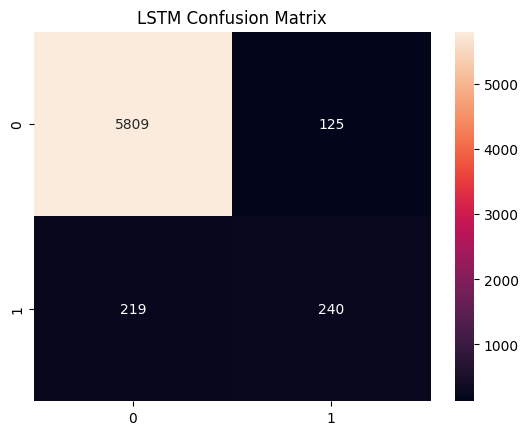

In [36]:
preds = (model_lstm.predict(X_test_pad) > 0.5).astype(int)
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.show()


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


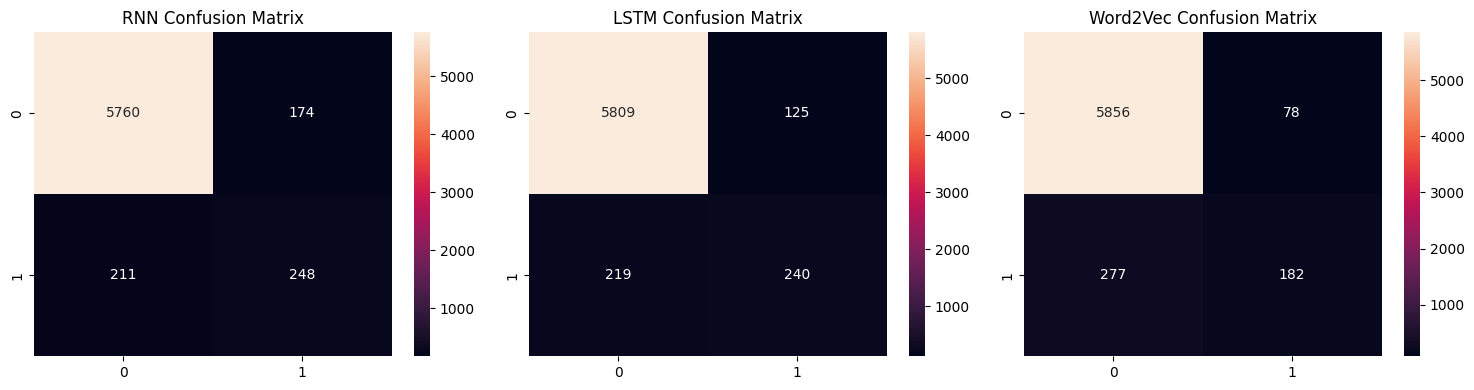

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model, name in zip(axes, [model_rnn, model_lstm, model_w2v], ['RNN', 'LSTM', 'Word2Vec']):
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

In [38]:
errors = []

preds = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

for i in range(len(preds)):
    if preds[i] != y_test.iloc[i]:
        errors.append((X_test.iloc[i], y_test.iloc[i], preds[i]))

for i in range(3):
    print(errors[i])


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
('allows amp baiter work station acceptable', np.int64(1), array([0]))
('twice read email yet answered', np.int64(0), array([1]))
('launched new amp haunted within scary', np.int64(0), array([1]))


## Error Analysis

**Possible reasons for misclassification:**
- Short or ambiguous tweets without clear sentiment markers
- Sarcasm or irony not captured by the model
- Rare words not covered by the GloVe vocabulary (OOV words)

**Model Complexity vs. Performance:**
- Simple RNN struggles with long-range dependencies
- LSTM handles sequential memory better but still limited by max_len
- Word2Vec LSTM benefits from pretrained semantics but frozen embeddings can't adapt

**Suggested Improvements:**
- Fine-tune embeddings (set trainable=True)
- Use bidirectional LSTM
- Increase vocabulary size or use subword tokenization
- Add more training data or use data augmentation

In [39]:
import gradio as gr

def predict_tweet(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model_lstm.predict(padded)[0][0]
    return "Racist and/or Sexist" if pred > 0.5 else "Not Racist or Sexist"

gr.Interface(fn=predict_tweet, inputs="text", outputs="text",
             title="Tweet Sentiment Classifier").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37c33f9a4da266e297.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [40]:
print("\nRNN MODEL")
model_rnn.summary()

print("\nLSTM MODEL")
model_lstm.summary()

print("\nWORD2VEC MODEL")
model_w2v.summary()


RNN MODEL


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 11, 64)         │     1,162,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,512,261 (13.40 MB)

 Trainable params: 1,170,753 (4.47 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 11, 50)         │       908,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 996,667 (3.80 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 908,150 (3.46 MB)

 Optimizer params: 59,012 (230.52 KB)